In [74]:
# customer price prediction classifier using logistic regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [75]:
df=pd.read_csv("/content/Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [76]:
# independent and dependent variables
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
# X → input features
# y → binary output (0 or 1)


In [77]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
dtypes: int64(2)
memory usage: 6.4 KB


In [78]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 400 entries, 0 to 399
Series name: Purchased
Non-Null Count  Dtype
--------------  -----
400 non-null    int64
dtypes: int64(1)
memory usage: 3.3 KB


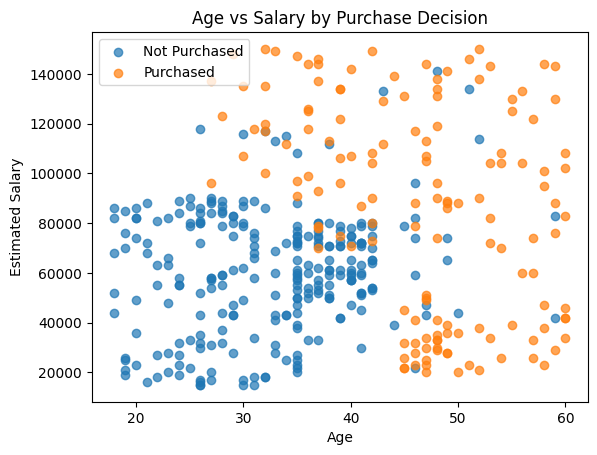

In [95]:
plt.scatter(
    df[df['Purchased'] == 0]['Age'],
    df[df['Purchased'] == 0]['EstimatedSalary'],
    label='Not Purchased',
    alpha=0.7
)
plt.scatter(
    df[df['Purchased'] == 1]['Age'],
    df[df['Purchased'] == 1]['EstimatedSalary'],
    label='Purchased',
    alpha=0.7
)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Age vs Salary by Purchase Decision')
plt.legend()
plt.show()


In [79]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)
# 80% training data
# 20% testing data
# random_state=0 → reproducibility

In [80]:
x_train.shape

(320, 2)

In [81]:
x_test.shape

(80, 2)

In [82]:
# Logistic regression is distance-based
# Different ranges (Age vs Salary) must be standardized
# Standardizes data to mean = 0 and standard deviation = 1.
# Mean = 0, Std = 1
# Not bounded (values can be negative)
# Less sensitive to outliers than MinMax
# Assumes data is roughly normally distributed
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)


In [83]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

# Learns probability of purchase using sigmoid function
# Output is probability, not a direct class

LogisticRegression()

In [84]:
# The sigmoid function is a mathematical function used mainly in Logistic Regression
#  to convert any real number into a probability between 0 and 1.
# Linear regression output → any value (−∞ to +∞)
# Sigmoid converts it into:
# Probability	Class
# ≥ 0.5	1 (Yes)
# < 0.5	0 (No)

In [85]:
y_pred = model.predict(x_test)
# Converts probabilities into classes using threshold
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [86]:
y_test.values

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1])

In [87]:
# model performance analysis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 92.5


In [88]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[58  0]
 [ 6 16]]


In [89]:
# Precision, Recall, F1-Score
print(classification_report(y_test, y_pred))

# Accuracy alone can be misleading
# F1-score balances precision & recall

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        58
           1       1.00      0.73      0.84        22

    accuracy                           0.93        80
   macro avg       0.95      0.86      0.90        80
weighted avg       0.93      0.93      0.92        80



In [90]:
coeff_df = pd.DataFrame({
    'Feature': ['Age', 'EstimatedSalary'],
    'Coefficient': model.coef_[0]
})

coeff_df


,Feature,Coefficient
0,Age,4.868552
1,EstimatedSalary,2.580585


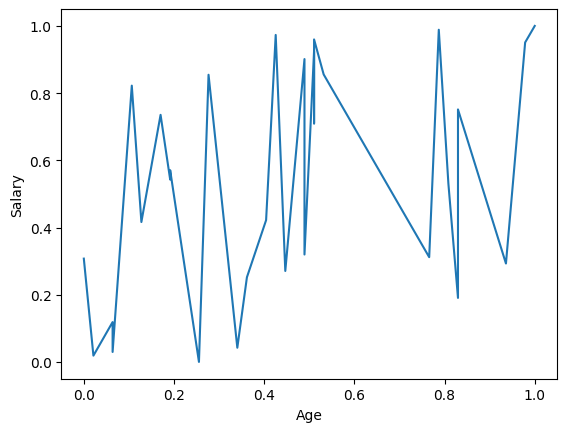

In [97]:
# EXAMPLE FOR SCALING AND NORMALIZATION
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
#random numbers will start from 0
# Fixes the starting point of random number generation
# Ensures same random numbers every time
# Helps in reproducibility
x1=np.random.randint(0,50,30)   #30 number of random integers (small scale (age))
x1=np.sort(x1)
x2=np.random.randint(10000,70000,30) # large scale (salary)

# scaling is imp as it scales the values at same level without any baising
x1_scaled = (x1 - x1.min()) / (x1.max() - x1.min())
x2_scaled = (x2 - x2.min()) / (x2.max() - x2.min())

plt.plot(x1_scaled, x2_scaled)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()